# Data Exploration: OULAD Dataset

**Bias-Aware Early Warning System for Higher Education**

*Author: John Baker*

## Overview

This document explores the Open University Learning Analytics Dataset (OULAD) to understand the data structure, distributions, and prepare for building a bias-aware Early Warning System (EWS).

**Research Goal:** Predict at-risk students within the first 25% of course completion while addressing algorithmic fairness across protected attributes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Data directory (relative to notebooks/)
DATA_DIR = Path("../data/raw")

## 1. Load Dataset

The OULAD consists of 7 interconnected tables. Let's load each one and examine its structure.

In [2]:
# Load all tables
student_info = pd.read_csv(DATA_DIR / "studentInfo.csv")
student_vle = pd.read_csv(DATA_DIR / "studentVle.csv")
student_assessment = pd.read_csv(DATA_DIR / "studentAssessment.csv")
student_registration = pd.read_csv(DATA_DIR / "studentRegistration.csv")
assessments = pd.read_csv(DATA_DIR / "assessments.csv")
vle = pd.read_csv(DATA_DIR / "vle.csv")
courses = pd.read_csv(DATA_DIR / "courses.csv")

# Summary of loaded data
tables = {
    "studentInfo": student_info,
    "studentVle": student_vle,
    "studentAssessment": student_assessment,
    "studentRegistration": student_registration,
    "assessments": assessments,
    "vle": vle,
    "courses": courses
}

print("Dataset Summary:")
print("-" * 50)
for name, df in tables.items():
    print(f"{name}: {len(df):,} rows, {len(df.columns)} columns")

Dataset Summary:
--------------------------------------------------
studentInfo: 32,593 rows, 12 columns
studentVle: 10,655,280 rows, 6 columns
studentAssessment: 173,912 rows, 5 columns
studentRegistration: 32,593 rows, 5 columns
assessments: 206 rows, 6 columns
vle: 6,364 rows, 6 columns
courses: 22 rows, 3 columns


## 2. Student Information (Target & Protected Attributes)

This table contains demographic information and the target variable (`final_result`).

In [3]:
print("Column names and types:")
print(student_info.dtypes)
print(f"\nShape: {student_info.shape}")
print(f"\nUnique students: {student_info['id_student'].nunique():,}")

Column names and types:
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object

Shape: (32593, 12)

Unique students: 28,785


### 2.1 Target Variable: Final Result

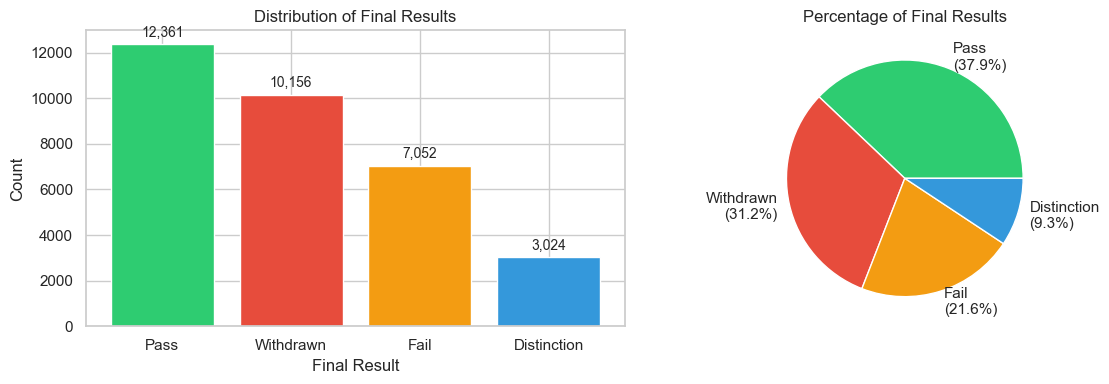


Final Result Distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
result_counts = student_info['final_result'].value_counts()
ax1 = axes[0]
bars = ax1.bar(result_counts.index, result_counts.values, color=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'])
ax1.set_xlabel('Final Result')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Final Results')
for bar, count in zip(bars, result_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{count:,}', ha='center', va='bottom', fontsize=10)

# Percentage
ax2 = axes[1]
result_pct = (result_counts / len(student_info) * 100).round(1)
ax2.pie(result_pct, labels=[f"{idx}\n({pct}%)" for idx, pct in zip(result_pct.index, result_pct.values)],
        colors=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'], autopct='')
ax2.set_title('Percentage of Final Results')

plt.tight_layout()
plt.show()

print("\nFinal Result Distribution:")
print(result_counts)

### 2.2 Binary Target Creation

For the EWS, we'll create a binary target: **At-Risk** (Withdrawn or Fail) vs **Not At-Risk** (Pass or Distinction).

In [5]:
# Create binary target
student_info['at_risk'] = student_info['final_result'].isin(['Withdrawn', 'Fail']).astype(int)

at_risk_counts = student_info['at_risk'].value_counts()
print("Binary Target Distribution:")
print(f"Not At-Risk (0): {at_risk_counts[0]:,} ({at_risk_counts[0]/len(student_info)*100:.1f}%)")
print(f"At-Risk (1): {at_risk_counts[1]:,} ({at_risk_counts[1]/len(student_info)*100:.1f}%)")

Binary Target Distribution:
Not At-Risk (0): 15,385 (47.2%)
At-Risk (1): 17,208 (52.8%)


### 2.3 Protected Attributes

These attributes will be used for fairness analysis.

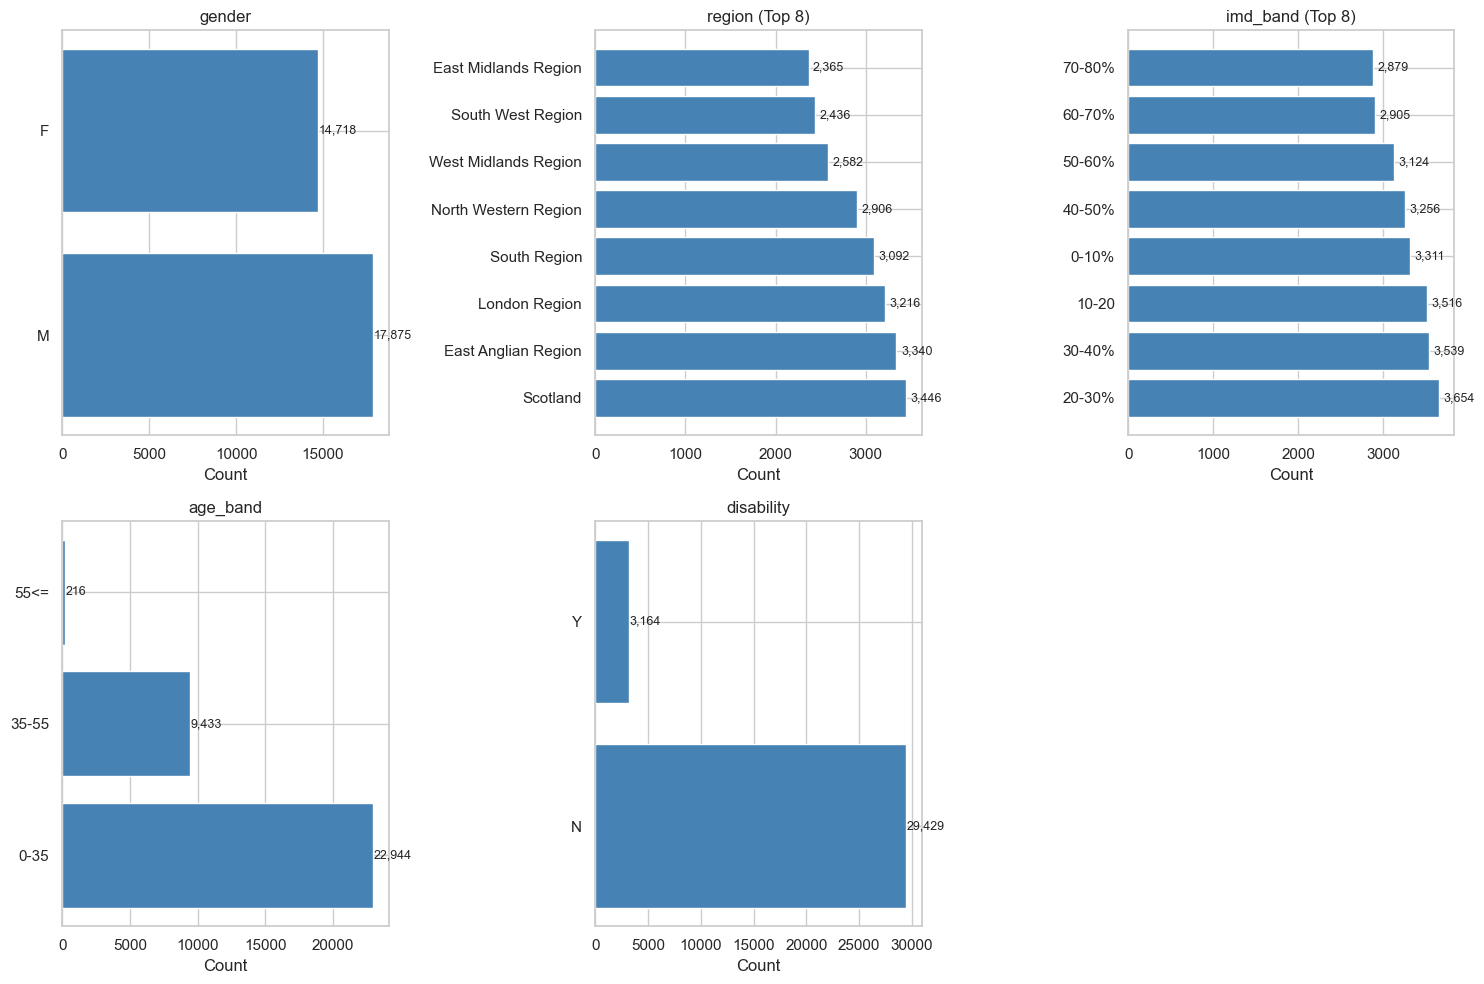

In [6]:
protected_attrs = ['gender', 'region', 'imd_band', 'age_band', 'disability']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, attr in enumerate(protected_attrs):
    ax = axes[i]
    counts = student_info[attr].value_counts()

    if len(counts) > 6:  # For region, show top categories
        counts = counts.head(8)
        ax.set_title(f'{attr} (Top 8)')
    else:
        ax.set_title(f'{attr}')

    bars = ax.barh(counts.index, counts.values, color='steelblue')
    ax.set_xlabel('Count')

    # Add count labels
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{count:,}', ha='left', va='center', fontsize=9)

# Remove empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

### 2.4 At-Risk Rate by Protected Attributes

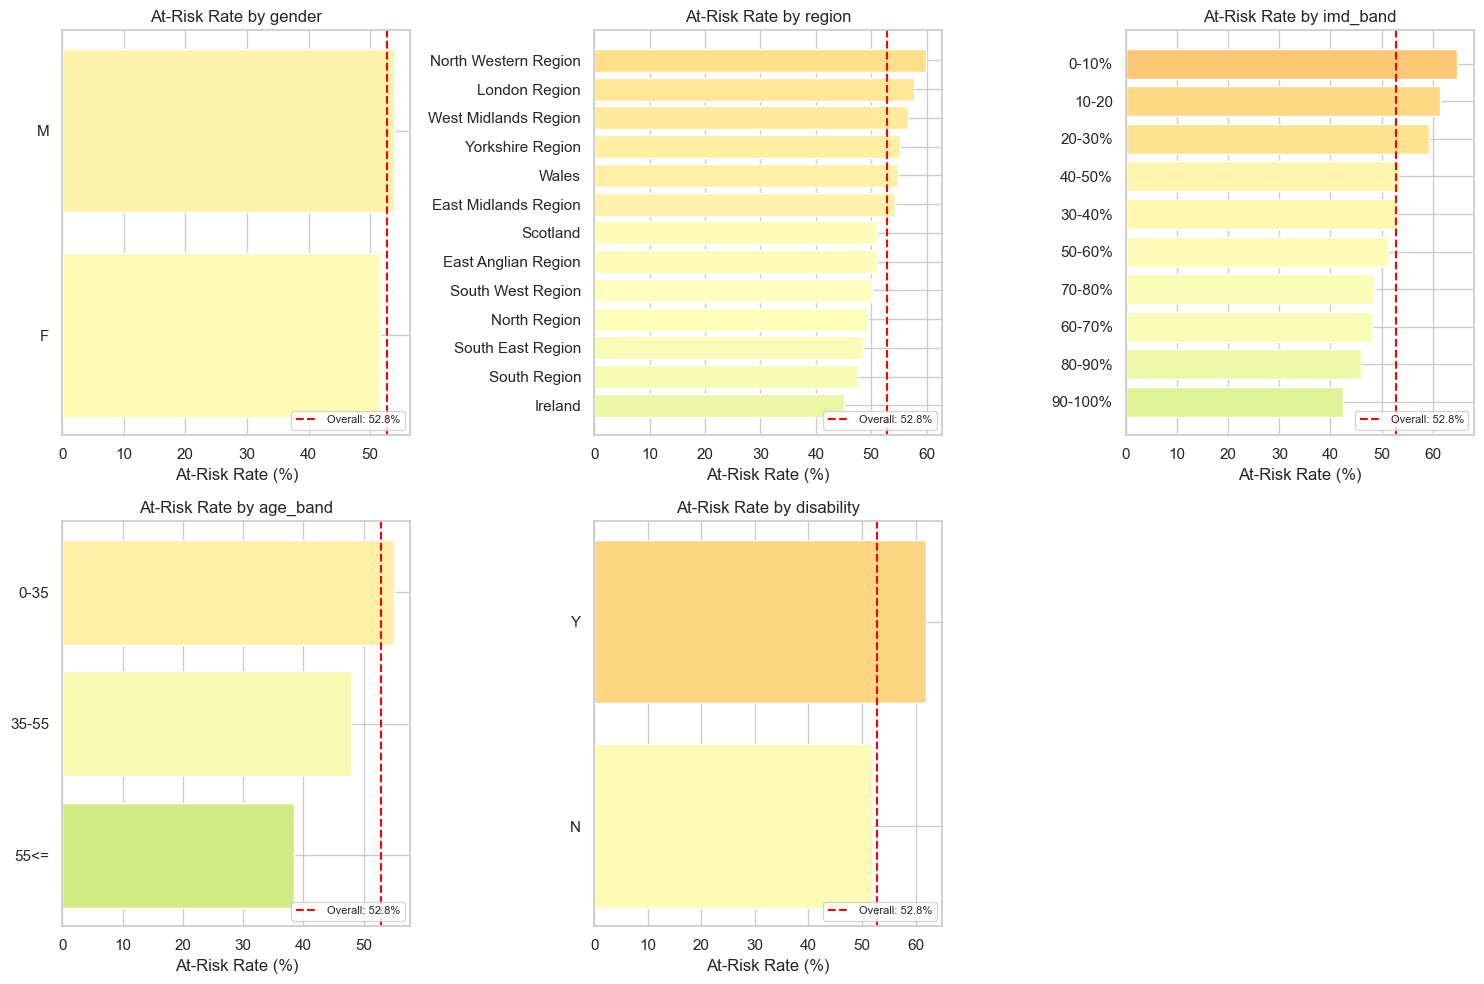

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, attr in enumerate(protected_attrs):
    ax = axes[i]

    # Calculate at-risk rate by group
    risk_rate = student_info.groupby(attr)['at_risk'].agg(['mean', 'count'])
    risk_rate.columns = ['at_risk_rate', 'n']
    risk_rate = risk_rate.sort_values('at_risk_rate', ascending=True)

    # Only show groups with sufficient samples
    risk_rate = risk_rate[risk_rate['n'] >= 100]

    colors = plt.cm.RdYlGn_r(risk_rate['at_risk_rate'])
    bars = ax.barh(risk_rate.index, risk_rate['at_risk_rate'] * 100, color=colors)
    ax.set_xlabel('At-Risk Rate (%)')
    ax.set_title(f'At-Risk Rate by {attr}')
    ax.axvline(x=student_info['at_risk'].mean() * 100, color='red', linestyle='--',
               label=f'Overall: {student_info["at_risk"].mean()*100:.1f}%')
    ax.legend(loc='lower right', fontsize=8)

axes[5].axis('off')
plt.tight_layout()
plt.show()

## 3. Course Information

Understanding course structure is critical for the 25% early prediction window.

In [8]:
print("Courses Overview:")
print(courses.to_string(index=False))

print("\nCourse length statistics:")
print(courses['module_presentation_length'].describe())

Courses Overview:
code_module code_presentation  module_presentation_length
        AAA             2013J                         268
        AAA             2014J                         269
        BBB             2013J                         268
        BBB             2014J                         262
        BBB             2013B                         240
        BBB             2014B                         234
        CCC             2014J                         269
        CCC             2014B                         241
        DDD             2013J                         261
        DDD             2014J                         262
        DDD             2013B                         240
        DDD             2014B                         241
        EEE             2013J                         268
        EEE             2014J                         269
        EEE             2014B                         241
        FFF             2013J                         

In [9]:
# Students per course-presentation
students_per_course = student_info.groupby(['code_module', 'code_presentation']).size().reset_index(name='n_students')
students_per_course = students_per_course.merge(courses, on=['code_module', 'code_presentation'])

print("\nStudents per Course-Presentation:")
print(students_per_course.to_string(index=False))


Students per Course-Presentation:
code_module code_presentation  n_students  module_presentation_length
        AAA             2013J         383                         268
        AAA             2014J         365                         269
        BBB             2013B        1767                         240
        BBB             2013J        2237                         268
        BBB             2014B        1613                         234
        BBB             2014J        2292                         262
        CCC             2014B        1936                         241
        CCC             2014J        2498                         269
        DDD             2013B        1303                         240
        DDD             2013J        1938                         261
        DDD             2014B        1228                         241
        DDD             2014J        1803                         262
        EEE             2013J        1052              

### 3.1 Calculate 25% Prediction Window

In [10]:
# Calculate 25% cutoff for each course
courses['early_window_day'] = (courses['module_presentation_length'] * 0.25).astype(int)

print("25% Early Prediction Window by Course:")
print(courses[['code_module', 'code_presentation', 'module_presentation_length', 'early_window_day']].to_string(index=False))

25% Early Prediction Window by Course:
code_module code_presentation  module_presentation_length  early_window_day
        AAA             2013J                         268                67
        AAA             2014J                         269                67
        BBB             2013J                         268                67
        BBB             2014J                         262                65
        BBB             2013B                         240                60
        BBB             2014B                         234                58
        CCC             2014J                         269                67
        CCC             2014B                         241                60
        DDD             2013J                         261                65
        DDD             2014J                         262                65
        DDD             2013B                         240                60
        DDD             2014B                    

## 4. Student VLE Interactions (Primary Temporal Feature)

This is the largest table with 10.6M records of student interactions with the Virtual Learning Environment.

In [11]:
print("VLE Interactions Overview:")
print(f"Total records: {len(student_vle):,}")
print(f"Unique students: {student_vle['id_student'].nunique():,}")
print("\nColumn types:")
print(student_vle.dtypes)
print("\nSample records:")
print(student_vle.head(10))

VLE Interactions Overview:
Total records: 10,655,280
Unique students: 26,074

Column types:
code_module          object
code_presentation    object
id_student            int64
id_site               int64
date                  int64
sum_click             int64
dtype: object

Sample records:
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1
5         AAA             2013J       28400   546652   -10          8
6         AAA             2013J       28400   546876   -10          2
7         AAA             2013J       28400   546688   -10         15
8         AAA             2013J       28400   546662   -10         17
9        

### 4.1 Interaction Patterns Over Time

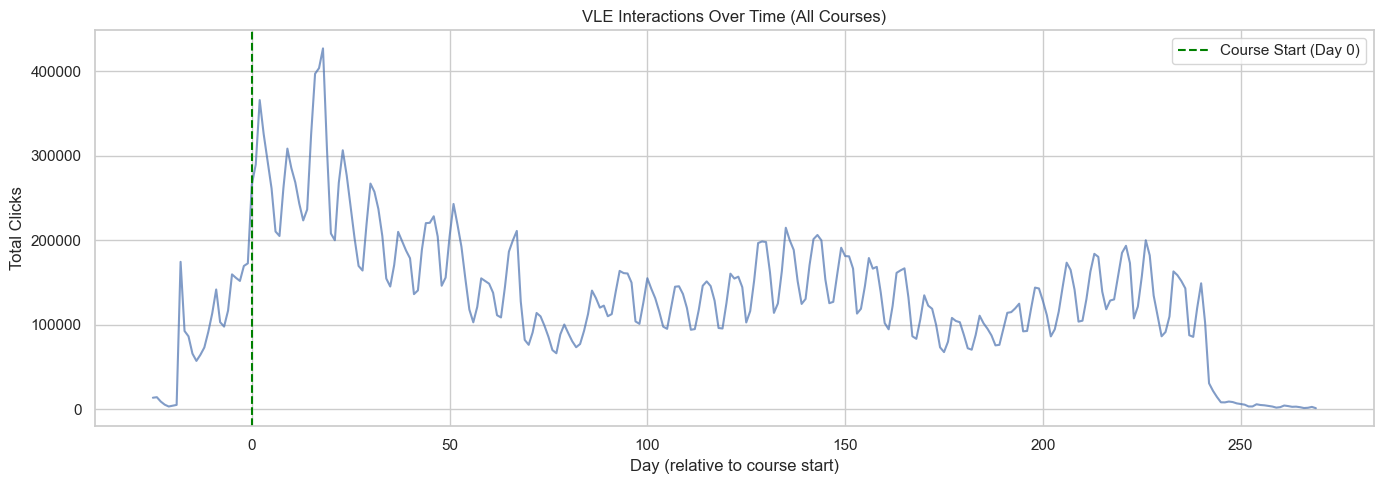


Date range: -25 to 269
Pre-course activity (date < 0): 688,988 records


In [12]:
# Aggregate clicks by day
daily_clicks = student_vle.groupby('date')['sum_click'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_clicks['date'], daily_clicks['sum_click'], alpha=0.7)
ax.set_xlabel('Day (relative to course start)')
ax.set_ylabel('Total Clicks')
ax.set_title('VLE Interactions Over Time (All Courses)')
ax.axvline(x=0, color='green', linestyle='--', label='Course Start (Day 0)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nDate range: {student_vle['date'].min()} to {student_vle['date'].max()}")
print(f"Pre-course activity (date < 0): {(student_vle['date'] < 0).sum():,} records")

### 4.2 VLE Activity Types

VLE Activity Types:
activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
glossary            21
ouelluminate        21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64


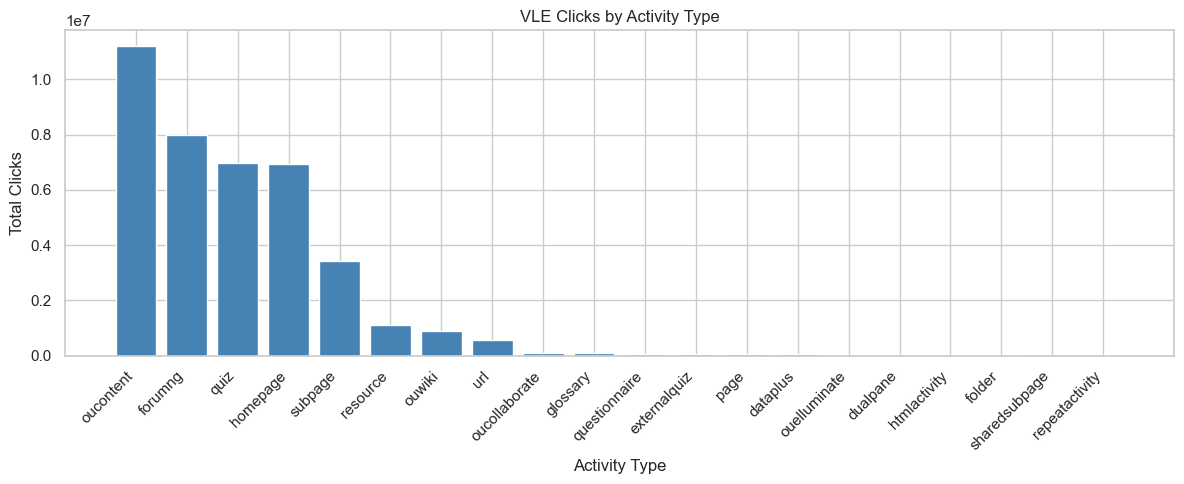

In [13]:
print("VLE Activity Types:")
print(vle['activity_type'].value_counts())

# Merge to get activity types for interactions
vle_with_type = student_vle.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')
activity_clicks = vle_with_type.groupby('activity_type')['sum_click'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(activity_clicks.index, activity_clicks.values, color='steelblue')
ax.set_xlabel('Activity Type')
ax.set_ylabel('Total Clicks')
ax.set_title('VLE Clicks by Activity Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Student Assessments

In [14]:
print("Assessments Table:")
print(assessments.head(10))
print(f"\nAssessment types: {assessments['assessment_type'].value_counts().to_dict()}")

print("\nStudent Assessment Submissions:")
print(student_assessment.head(10))
print(f"\nTotal submissions: {len(student_assessment):,}")

Assessments Table:
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0
5         AAA             2013J           1757            Exam    NaN   100.0
6         AAA             2014J           1758             TMA   19.0    10.0
7         AAA             2014J           1759             TMA   54.0    20.0
8         AAA             2014J           1760             TMA  117.0    20.0
9         AAA             2014J           1761             TMA  166.0    20.0

Assessment types: {'TMA': 106, 'CMA': 76, 'Exam': 24}

Student Assessment Submissions:
   id_assessment  id_student  date_

### 5.1 Assessment Scores Distribution

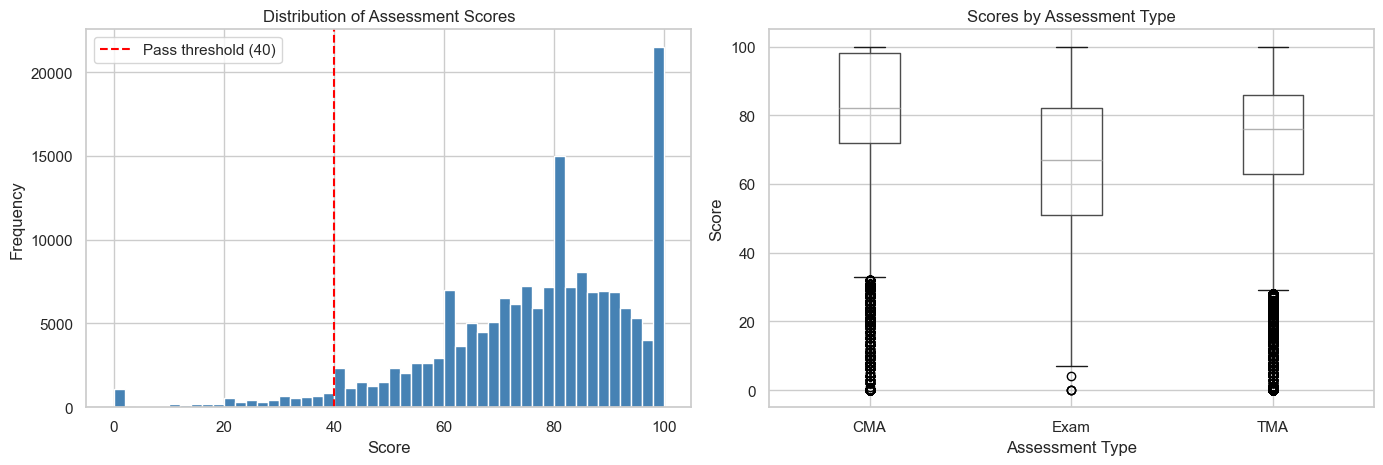

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall score distribution
ax1 = axes[0]
student_assessment['score'].hist(bins=50, ax=ax1, color='steelblue', edgecolor='white')
ax1.axvline(x=40, color='red', linestyle='--', label='Pass threshold (40)')
ax1.set_xlabel('Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Assessment Scores')
ax1.legend()

# Score by assessment type
ax2 = axes[1]
merged_assess = student_assessment.merge(assessments[['id_assessment', 'assessment_type']], on='id_assessment')
merged_assess.boxplot(column='score', by='assessment_type', ax=ax2)
ax2.set_xlabel('Assessment Type')
ax2.set_ylabel('Score')
ax2.set_title('Scores by Assessment Type')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 6. Missing Data Analysis

In [16]:
print("Missing Values by Table:")
print("-" * 50)

for name, df in tables.items():
    missing = df.isnull().sum()
    if missing.any():
        print(f"\n{name}:")
        print(missing[missing > 0])
    else:
        print(f"\n{name}: No missing values")

Missing Values by Table:
--------------------------------------------------

studentInfo:
imd_band    1111
dtype: int64

studentVle: No missing values

studentAssessment:
score    173
dtype: int64

studentRegistration:
date_registration         45
date_unregistration    22521
dtype: int64

assessments:
date    11
dtype: int64

vle:
week_from    5243
week_to      5243
dtype: int64

courses: No missing values


In [17]:
# Special focus on imd_band (key socioeconomic indicator)
print("\nIMD Band Analysis:")
print(f"Missing: {student_info['imd_band'].isnull().sum():,} ({student_info['imd_band'].isnull().mean()*100:.1f}%)")
print("\nDistribution:")
print(student_info['imd_band'].value_counts(dropna=False))


IMD Band Analysis:
Missing: 1,111 (3.4%)

Distribution:
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64


## 7. Summary Statistics

In [18]:
# Key statistics for modeling
print("=" * 60)
print("SUMMARY STATISTICS FOR MODELING")
print("=" * 60)

print("\n1. SAMPLE SIZE")
print(f"   Total student-course records: {len(student_info):,}")
print(f"   Unique students: {student_info['id_student'].nunique():,}")

print("\n2. TARGET VARIABLE (At-Risk)")
print(f"   At-Risk (Withdrawn/Fail): {student_info['at_risk'].sum():,} ({student_info['at_risk'].mean()*100:.1f}%)")
print(f"   Not At-Risk (Pass/Distinction): {(1-student_info['at_risk']).sum():,} ({(1-student_info['at_risk'].mean())*100:.1f}%)")

print("\n3. PROTECTED ATTRIBUTES")
for attr in protected_attrs:
    n_categories = student_info[attr].nunique()
    missing_pct = student_info[attr].isnull().mean() * 100
    print(f"   {attr}: {n_categories} categories, {missing_pct:.1f}% missing")

print("\n4. TEMPORAL DATA")
print(f"   VLE interactions: {len(student_vle):,}")
print(f"   Assessment submissions: {len(student_assessment):,}")

print("\n5. COURSE LENGTHS")
print(f"   Range: {courses['module_presentation_length'].min()}-{courses['module_presentation_length'].max()} days")
print(f"   25% window range: {courses['early_window_day'].min()}-{courses['early_window_day'].max()} days")

SUMMARY STATISTICS FOR MODELING

1. SAMPLE SIZE
   Total student-course records: 32,593
   Unique students: 28,785

2. TARGET VARIABLE (At-Risk)
   At-Risk (Withdrawn/Fail): 17,208 (52.8%)
   Not At-Risk (Pass/Distinction): 15,385 (47.2%)

3. PROTECTED ATTRIBUTES
   gender: 2 categories, 0.0% missing
   region: 13 categories, 0.0% missing
   imd_band: 10 categories, 3.4% missing
   age_band: 3 categories, 0.0% missing
   disability: 2 categories, 0.0% missing

4. TEMPORAL DATA
   VLE interactions: 10,655,280
   Assessment submissions: 173,912

5. COURSE LENGTHS
   Range: 234-269 days
   25% window range: 58-67 days


## 8. Next Steps

Based on this exploration, the next steps are:

1. **Feature Engineering**
   - Aggregate VLE interactions within 25% window per student
   - Calculate engagement metrics (total clicks, unique days active, activity diversity)
   - Summarize early assessment performance

2. **Handle Missing Data**
   - Address missing `imd_band` values (key socioeconomic indicator)
   - Handle missing `date_unregistration` (only for withdrawn students)

3. **Temporal Sequence Creation**
   - Create time-series features for LSTM input
   - Define appropriate sequence length and padding strategy

4. **Train/Test Split Strategy**
   - Consider splitting by course presentation to avoid data leakage
   - Stratify by target and protected attributes